<a href="https://colab.research.google.com/github/nalinkai/Data-Science-Project-Lifecycle/blob/Dev/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("/content/sample_data/project_cycle cw/Hotel-A-train_finalized.csv")

df.head()

,Reservation-id,Age,Income,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Reservation_Status,Discount_Rate,...,Educational_Level_high-school,Educational_Level_mid-school,Meal_Type_fb,Meal_Type_hb,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,39428300,40,0.000000,2,2,0,0,0,check-out,0.250,...,False,False,False,FALSE,False,False,False,True,True,True
1,77491756,49,0.666667,3,3,0,0,0,check-out,0.000,...,False,True,False,FALSE,False,True,False,True,True,False
2,73747291,42,0.000000,3,3,0,0,0,check-out,0.000,...,False,False,False,FALSE,False,False,False,True,True,False
3,67301739,25,1.000000,4,3,0,0,0,check-out,0.125,...,False,False,False,FALSE,False,True,False,False,True,True
4,77222321,62,0.333333,1,1,0,0,0,check-out,0.250,...,True,False,False,FALSE,False,False,True,False,False,True


In [ ]:
df.shape
df.columns
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12675 entries, 0 to 12674
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Reservation-id                  12675 non-null  int64  
 1   Age                             12675 non-null  int64  
 2   Income                          12675 non-null  float64
 3   Adults                          12675 non-null  int64  
 4   Children                        12675 non-null  int64  
 5   Babies                          12675 non-null  int64  
 6   Visted_Previously               12675 non-null  int64  
 7   Previous_Cancellations          12675 non-null  int64  
 8   Reservation_Status              12675 non-null  object 
 9   Discount_Rate                   12675 non-null  float64
 10  Room_Rate                       12675 non-null  float64
 11  lead_time_days                  12675 non-null  int64  
 12  stay_duration_days              

,Reservation-id,Age,Income,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Discount_Rate,Room_Rate,...,previous_stays_cancelled_ratio,is_online_booking,is_direct_booking,is_agent_booking,used_promotion,price_per_person,lead_time_price_interaction,cancellation_risk,stays_include_weekend,Reservation_Status_encoded
count,1.267500e+04,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,...,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000,12675.000000
mean,4.967463e+07,44.038501,0.429665,2.347298,1.737278,0.352899,0.334280,0.113215,0.311371,0.499599,...,0.056607,0.567022,0.290178,0.142801,0.750927,0.099348,57.379228,0.034339,0.349665,0.998185
std,2.876129e+07,15.354774,0.343162,1.186665,0.722021,0.573085,0.471757,0.316868,0.278722,0.292920,...,0.158434,0.495507,0.453862,0.349883,0.432493,0.066847,62.255571,0.134049,0.476883,0.091002
min,4.989000e+03,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.493357e+07,31.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.125000,0.246667,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.045000,12.070000,0.000000,0.000000,1.000000
50%,4.972148e+07,44.000000,0.333333,2.000000,2.000000,0.000000,0.000000,0.000000,0.250000,0.493333,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.091429,36.213333,0.000000,0.000000,1.000000
75%,7.439234e+07,57.000000,0.666667,3.000000,2.000000,1.000000,1.000000,0.000000,0.500000,0.760000,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.142857,82.160000,0.000000,1.000000,1.000000
max,9.999486e+07,70.000000,1.000000,5.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,...,0.500000,1.000000,1.000000,1.000000,1.000000,0.333333,519.360000,1.000000,1.000000,2.000000


In [ ]:
target = "Reservation_Status_encoded"

In [ ]:
X = df.drop(["Reservation_Status", "Reservation_Status_encoded", "Reservation-id"], axis=1)
y = df["Reservation_Status_encoded"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import numpy as np

# Identify columns in X_train and X_test that are of 'object' type
object_cols_train = X_train.select_dtypes(include='object').columns
object_cols_test = X_test.select_dtypes(include='object').columns

# For X_train
for col in object_cols_train:
    # Convert 'FALSE' (string) to False (boolean), 'True' (string) to True (boolean)
    # Handle potential mixed casing by converting to string and then lowercasing
    # Then explicitly map to 0 or 1, and fill any NaN (from unmappable values) with 0
    X_train[col] = X_train[col].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0).astype(int)

# For X_test
for col in object_cols_test:
    X_test[col] = X_test[col].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0).astype(int)

# Now, all boolean-like object columns should be integers (0 or 1).
# The remaining columns (already numeric or already processed) can be converted to int.
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [ ]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9913214990138067

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.99      1.00      1.00      2513
           2       0.00      0.00      0.00         9

    accuracy                           0.99      2535
   macro avg       0.33      0.33      0.33      2535
weighted avg       0.98      0.99      0.99      2535


Confusion Matrix:
 [[   0   13    0]
 [   0 2513    0]
 [   0    9    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

,0
lead_time_price_interaction,0.085426
lead_time_days,0.081188
booking_day,0.068398
Age,0.066781
booking_month,0.048887
total_guests,0.041454
checkout_month,0.038190
checkin_month,0.036205
checkin_dayofweek,0.035811
checkout_dayofweek,0.033952


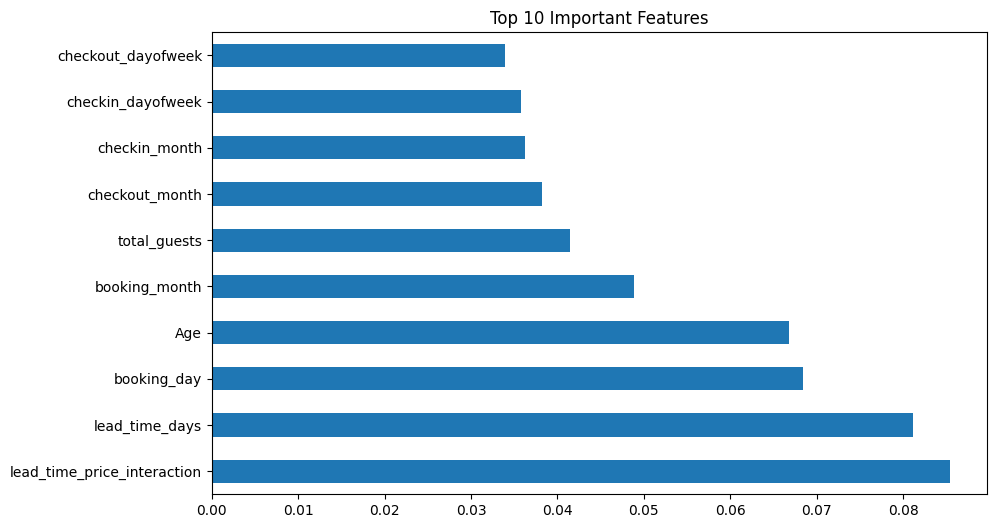

In [ ]:
plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

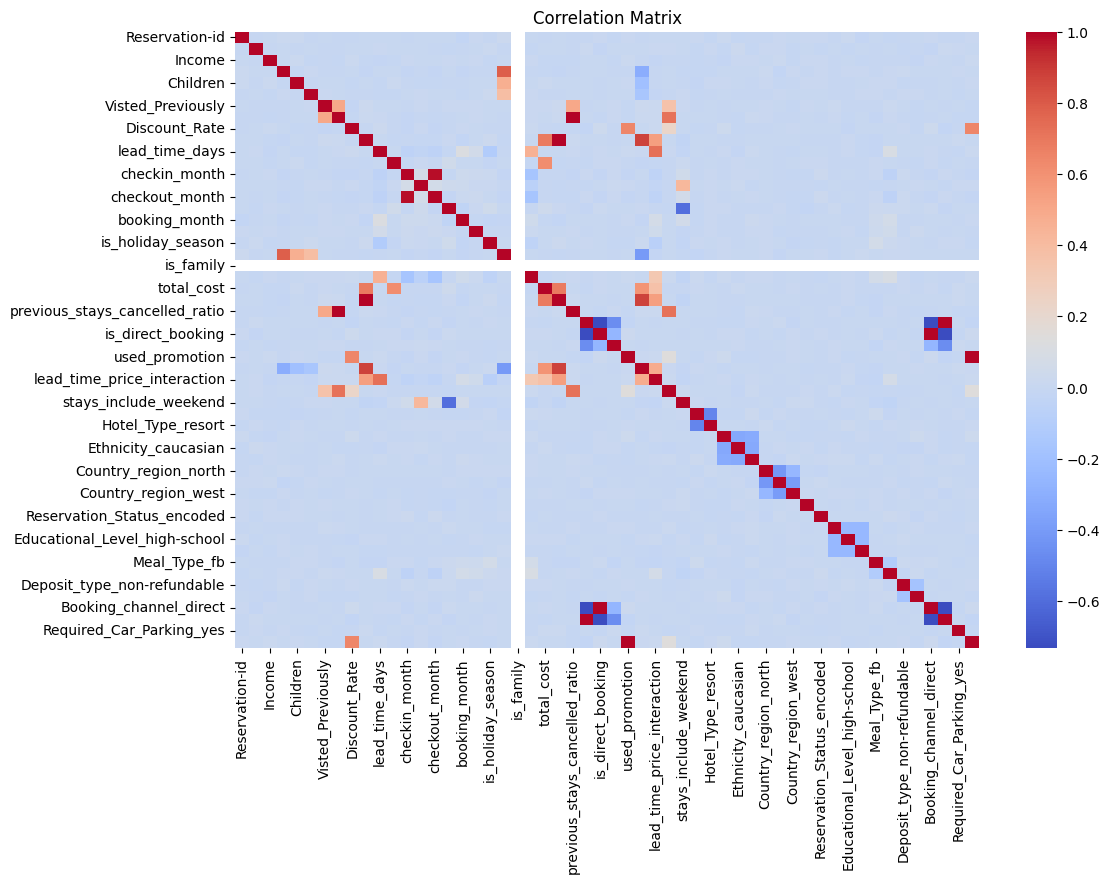

In [ ]:
# Create a copy of the DataFrame to perform transformations for correlation calculation
df_numeric = df.copy()

# Drop the original 'Reservation_Status' column as 'Reservation_Status_encoded' is available
df_numeric = df_numeric.drop(columns=['Reservation_Status'])

# Identify object columns that are not 'Reservation-id' (which is not typically used in correlation)
object_cols = df_numeric.select_dtypes(include='object').columns

# Convert boolean-like object columns to integers (0 or 1)
for col in object_cols:
    # Convert to string, then lowercase, map 'true'/'false' to 1/0, fill NaN with 0, and convert to int
    df_numeric[col] = df_numeric[col].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0).astype(int)

plt.figure(figsize=(12,8))
# Calculate correlation on the numeric DataFrame
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()